# Week 01: Sunspot Butterfly Diagram

This notebook reads the provided sunspot group catalog and plots the classic solar "butterfly diagram" (latitude vs time of emergence).

## 1) Setup (run this first)

This project is designed to run on Google Colab. Run the setup cell below to install dependencies and configure the environment.

In [1]:
# Standard ButterflAI Colab setup — always run this first
import os
import subprocess
import sys

repo_path = "/content/butterflai"
if not os.path.isdir(repo_path):
    subprocess.run(
        ["git", "clone", "https://github.com/SwRI-IDEA-Lab/butterflai.git", repo_path],
        check=True,
    )
else:
    subprocess.run(["git", "-C", repo_path, "pull"], check=True)

sys.path.insert(0, repo_path)
from infrastructure.utils.colab_setup import setup
setup()


  Installing from /content/butterflai/requirements.txt...

🦋 ButterflAI environment ready
   Runtime  : Google Colab
   Device   : cpu
   Seed     : 42


{'in_colab': True,
 'device': device(type='cpu'),
 'seed': 42,
 'drive_mounted': False,
 'data_path': None}

## 2) Load the Sunspot Group Catalog

We use the provided  file, which contains daily sunspot group measurements from 1825–2023.

In [2]:
import pandas as pd
from pathlib import Path

data_path = Path(repo_path) / 'data' / 'composite_sunspot_groups_daily_measurements_10_23.csv'
df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
df.rename(columns={"year_month_day": "date"}, inplace=True)

# Keep only rows with valid latitude (sunspot groups)
df = df[df["latitude"].notna()].copy()

# Quick sanity check
df[["date", "latitude", "CYCLE"]].head()


/tmp/ipykernel_274/1667494998.py:5: FutureWarning: The 'keep_date_col' keyword in pd.read_csv is deprecated and will be removed in a future version. Explicitly remove unwanted columns after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
/tmp/ipykernel_274/1667494998.py:5: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)


,date,latitude,CYCLE
0,1825-11-05,-1.2,NaN
3,1825-11-08,-17.9,NaN
4,1825-11-09,-14.6,NaN
5,1825-11-10,-27.4,NaN
6,1825-11-11,-26.3,NaN


## 3) Plot the Butterfly Diagram

We plot emergence latitude vs. date. Points are colored by hemisphere (north vs south).

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


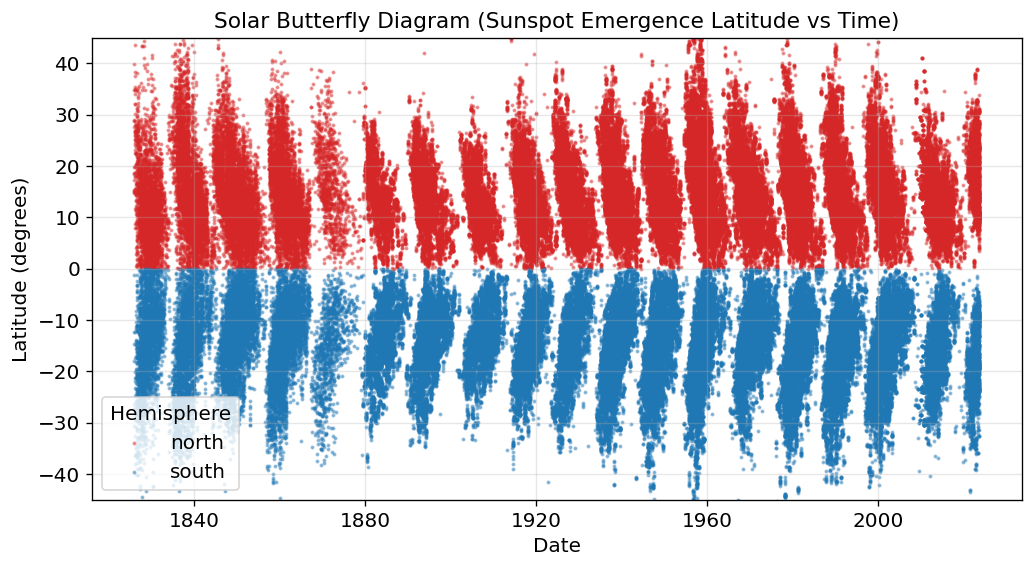

In [3]:
import matplotlib.pyplot as plt

df["hemisphere"] = df["latitude"].apply(lambda v: "north" if v >= 0 else "south")
colors = {"north": "tab:red", "south": "tab:blue"}

fig, ax = plt.subplots(figsize=(10, 5))
for hemi, group in df.groupby("hemisphere"):
    ax.scatter(group["date"], group["latitude"], s=2, c=colors[hemi], label=hemi, alpha=0.4)

ax.set_title("Solar Butterfly Diagram (Sunspot Emergence Latitude vs Time)")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere")
ax.set_ylim(-45, 45)
plt.show()


## 4) Exercise: Visualize Individual Solar Cycles

The butterfly diagram shows all cycles overlaid. Create a visualization that focuses on a single solar cycle (e.g., cycle 24, which is recent and well-observed).

**Task:**
- Filter the data to a specific cycle (use the  column).
- Plot the butterfly diagram for just that cycle.
- Experiment with different cycles and note any differences in shape or amplitude.

**Hint:** You can use the cycle column to filter.


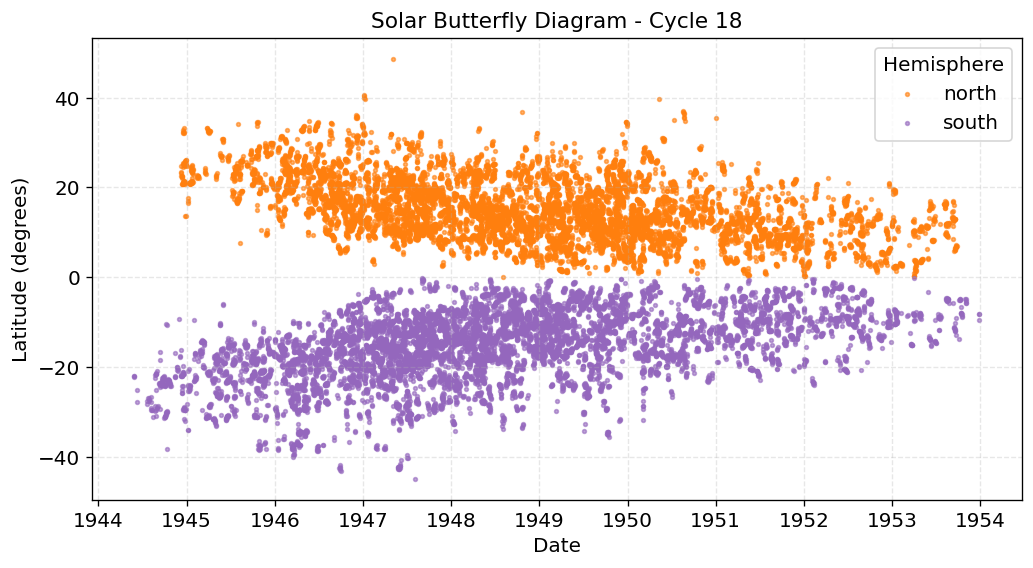

In [10]:
import matplotlib.pyplot as plt

# Choose a specific cycle (e.g., Cycle 24)
cycle_number = 18
cycle_df = df[df["CYCLE"] == cycle_number].copy()

# Define colors for hemispheres
cycle_df["hemisphere"] = cycle_df["latitude"].apply(lambda v: "north" if v >= 0 else "south")
colors = {"north": "tab:orange", "south": "tab:purple"}

fig, ax = plt.subplots(figsize=(10, 5))

for hemi, group in cycle_df.groupby("hemisphere"):
    ax.scatter(group["date"], group["latitude"], s=5, c=colors[hemi], label=hemi, alpha=0.6)

ax.set_title(f"Solar Butterfly Diagram - Cycle {cycle_number}")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere")
ax.grid(True, linestyle='--', alpha=0.3)
plt.show()

In [11]:
# Checking the range of dates and cycles available in the dataset
print(f"Earliest date: {df['date'].min()}")
print(f"Latest date:   {df['date'].max()}")
print(f"Available Cycle numbers: {sorted(df['CYCLE'].dropna().unique().astype(int))}")

print(f"\nRows with missing Cycle numbers: {df['CYCLE'].isna().sum()}")

# I was curious at how far back the data went and if it went back to one also about how this data was obtained

Earliest date: 1825-11-05 00:00:00
Latest date:   2023-10-16 00:00:00
Available Cycle numbers: [np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25)]

Rows with missing Cycle numbers: 1574


## 5) Exercise: Calculate Mean Latitudinal Paths

The "wings" of the butterfly diagram show the average latitude of sunspot emergence over time for each hemisphere.

**Task:**
- Group the data by hemisphere and calculate the mean latitude for each month/year.
- Plot the mean latitudinal path for the northern and southern hemispheres separately.
- Discuss: What does this tell us about the solar cycle's evolution?

**Hint:** Use  with  and date aggregation (e.g., resample by year).


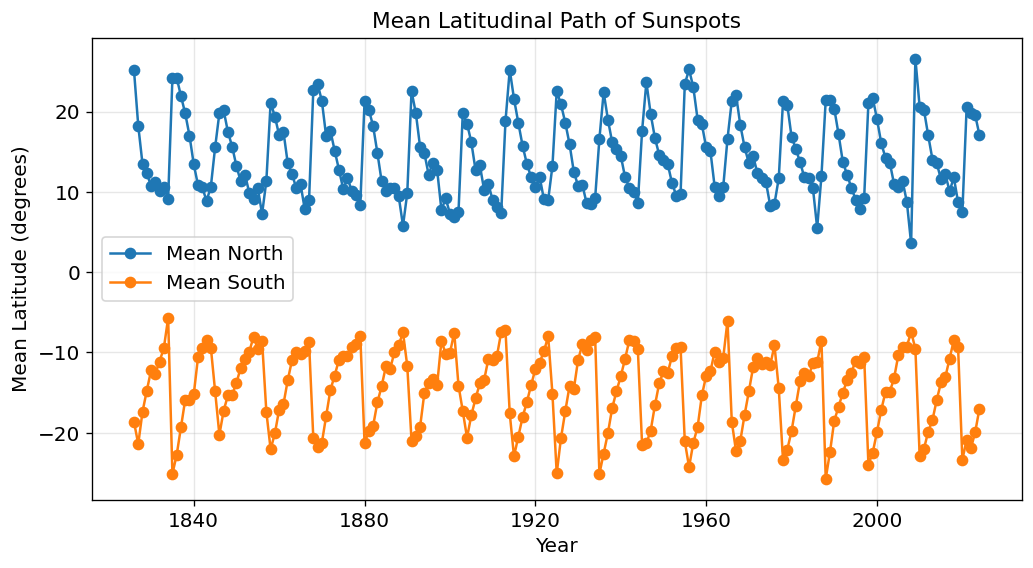

In [13]:
import matplotlib.pyplot as plt

# Group by hemisphere and resample by year to find the mean latitude
df_mean = df.set_index('date').groupby(['hemisphere', pd.Grouper(freq='YE')])['latitude'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))

for hemi in ['north', 'south']:
    hemi_df = df_mean[df_mean['hemisphere'] == hemi]
    ax.plot(hemi_df['date'], hemi_df['latitude'], marker='o', label=f'Mean {hemi.capitalize()}')

ax.set_title("Mean Latitudinal Path of Sunspots")
ax.set_xlabel("Year")
ax.set_ylabel("Mean Latitude (degrees)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

# As solar cycles progress, sunspot production moves towards the equator from higher latitudes
# This rough 'sabertooth' pattern repeats over time (seems to start over with each cycle)

## 6) Reflection: Best Practices for AI-Assisted Learning

Throughout this program, you'll be working with AI assistants (like GitHub Copilot or Claude) to help with coding and understanding concepts.

**Task:**
- Ask your AI assistant: "What is the best way to prompt an AI assistant to help me learn machine learning and solar physics concepts effectively?"
- Write down their response and reflect: How will you apply this advice in future notebooks?

**Hint:** Be specific about what you want to learn and how you want the AI to explain it.


*Your reflection here:*


I hope to use AI as a vehicle between coding language and what I bring to the table with direction, inquiry and constraints.

Indeed, I find myself much more engaged by the framework of why and how physical phenomena function as well as the meanings, intepretations and uncertainties of data.

The response from Gemini gets at the things that I need to keep in mind in using AI as a translator from intention to syntax so to speak, whether in always ensuring I ask it for clarification to understand and be able to explain the underlying physics as well as other methodological details (e.g. normalization, regression, aggregegation etc).

In a similar vein, I also need to provide quality control in questioning the assumptions it makes as well as developing my overall verification ability, namely assessing its outputs to see if they make visual/physical sense as well as testing different ideas & possibilities for a task and evaluating their validity & efficacy.



### Guide to Effective AI-Assisted Learning

To maximize your growth in complex fields like machine learning and solar physics, it is essential to treat AI as a mentor rather than just a code generator. Using goal-oriented prompts helps ensure you are building a deep conceptual understanding.

#### Goal-Oriented Prompting Techniques

1. **First Principles (The 'Why' behind the 'How')**
   - **Concept:** Instead of just asking for a formula or a model, ask the AI to explain the underlying physics or mathematical logic.
   - **Example:** "Explain the physical mechanism that causes sunspots to migrate toward the solar equator from first principles."

2. **Code Walkthroughs**
   - **Concept:** When presented with complex data processing or plotting scripts, request a step-by-step breakdown. This helps you understand how data transforms from raw input to a final visualization like the butterfly diagram.
   - **Example:** "Walk me through this pandas resampling code line-by-line and explain how it handles the time-series aggregation for solar cycles."

3. **Socratic Questioning**
   - **Concept:** If you are stuck on a problem, ask the AI to guide you with hints rather than providing the solution immediately. This encourages active recall and problem-solving.
   - **Example:** "I'm trying to filter this sunspot dataset by cycle number but I'm getting an error. Don't give me the code yet; instead, give me three Socratic hints to help me debug the logic myself."

**Pro-Tip:** Always follow up an AI's explanation by summarizing what you learned in your own words. This 'active engagement' is the fastest way to master new technical domains.